# Inferência — Segmentação de Instâncias (DSB2018)

Recebe o caminho de uma imagem e devolve:
- a máscara de instâncias colorida 
- a contagem de núcleos detectados

Para usar: edite o caminho na célula "CONFIGURAÇÃO" abaixo e rode todas as células.

In [16]:
import numpy as np
import cv2
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from src.models.resunet import ResUNet
from src.postprocessing.watershed_decode import decode_watershed

## Configuração

Edite o caminho da imagem se necessário.

In [17]:
IMAGE_PATH = "data\\raw\\stage1_test\\53df5150ee56253fe5bc91a9230d377bb21f1300f443ba45a758bcb01a15c0e4\\images\\53df5150ee56253fe5bc91a9230d377bb21f1300f443ba45a758bcb01a15c0e4.png"
CHECKPOINT_PATH = "outputs/resunet_3class.pt"
MODEL_INPUT_SIZE = (128, 128)  # tamanho usado no treino -- a imagem é redimensionada para isso antes da inferência

## Carregamento do modelo

Carrega o checkpoint já treinado. Nenhum treino acontece aqui.

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

model = ResUNet(in_channels=3, num_classes=3, base_channels=32).to(device)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()
print(f"Checkpoint carregado de: {CHECKPOINT_PATH}")

Usando device: cuda
Checkpoint carregado de: outputs/resunet_3class.pt


## Pré-processamento

Lê a imagem, converte para RGB, normaliza e redimensiona para o tamanho esperado pelo modelo.

In [19]:
def load_and_preprocess(image_path, target_size):
    image = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)
    if image is None:
        raise FileNotFoundError(f"Não foi possível abrir a imagem: {image_path}")

    original_size = image.shape[:2]  # (H, W) original, para devolver a máscara nesse tamanho depois

    if image.ndim == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    elif image.shape[2] == 4:
        image = cv2.cvtColor(image, cv2.COLOR_BGRA2RGB)
    elif image.shape[2] == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = image.astype(np.float32) / 255.0
    image_resized = cv2.resize(image, (target_size[1], target_size[0]), interpolation=cv2.INTER_AREA)

    image_tensor = torch.from_numpy(image_resized).float().permute(2, 0, 1)  # (3, H, W)
    return image_tensor, image_resized, original_size


image_tensor, image_resized_np, original_size = load_and_preprocess(IMAGE_PATH, MODEL_INPUT_SIZE)
print(f"Tamanho original da imagem: {original_size}")
print(f"Redimensionada para: {MODEL_INPUT_SIZE}.")

Tamanho original da imagem: (256, 256)
Redimensionada para: (128, 128).


## Inferência

Roda o modelo, aplica softmax e decodifica via watershed.

In [20]:
with torch.no_grad():
    logits = model(image_tensor.unsqueeze(0).to(device))            # (1, 3, H, W)
    probs = F.softmax(logits, dim=1)[0].cpu().numpy()                # (3, H, W): fundo, interior, borda

instance_mask = decode_watershed(probs)                              # (H, W) int, 0 = fundo, 1..N = núcleos

# devolve a máscara para o tamanho original da imagem, preservando os IDs (nearest neighbor)
instance_mask_original_size = cv2.resize(
    instance_mask.astype(np.int32),
    (original_size[1], original_size[0]),
    interpolation=cv2.INTER_NEAREST,
)

n_instances = int(instance_mask_original_size.max())
print(f"Núcleos detectados: {n_instances}")

Núcleos detectados: 13


## Resultado: imagem original, mapa de borda intermediário, e máscara de instâncias colorida

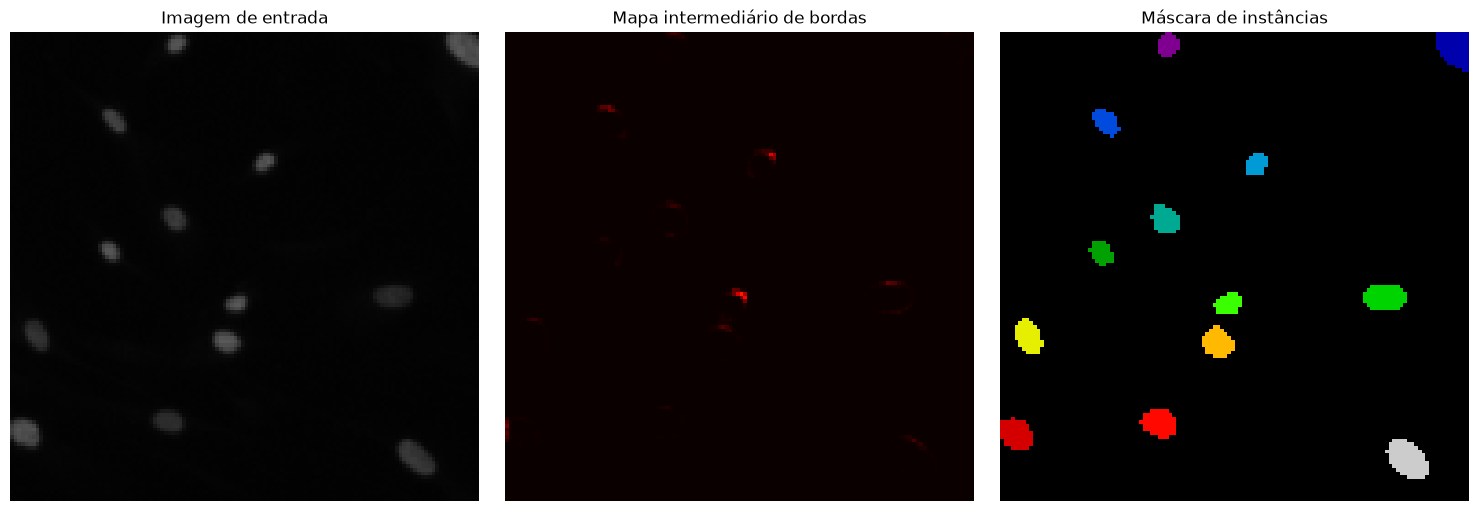


Resultado final: 13 núcleos detectados.


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_resized_np)
axes[0].set_title("Imagem de entrada")
axes[0].axis("off")

axes[1].imshow(probs[2], cmap="hot", vmin=0, vmax=1)
axes[1].set_title("Mapa intermediário de bordas")
axes[1].axis("off")

axes[2].imshow(instance_mask, cmap="nipy_spectral")
axes[2].set_title(f"Máscara de instâncias")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"\nResultado final: {n_instances} núcleos detectados.")

## (Opcional) Salvar a máscara de instâncias em disco

In [22]:
SAVE_OUTPUT = False  # mude para True para salvar
OUTPUT_PATH = "outputs/inference_result_mask.png"

if SAVE_OUTPUT:
    from pathlib import Path
    Path("outputs").mkdir(exist_ok=True)
    plt.imsave(OUTPUT_PATH, instance_mask_original_size, cmap="nipy_spectral")
    print(f"Máscara salva em {OUTPUT_PATH}")